In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Hugging Face

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [2]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/markerpenspanseg/train/images")
count_images("datasets/markerpenspanseg/valid/images")

Total images: 239
Total images: 30


In [3]:
# Check train annotations
with open("datasets/markerpenspanseg/train/_annotations.coco.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("datasets/markerpenspanseg/valid/_annotations.coco.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 239
Train annotations: 956
Categories: [{'id': 0, 'name': 'caps-7o2C-zaFi', 'supercategory': 'none'}, {'id': 1, 'name': 'CAP', 'supercategory': 'caps-7o2C-zaFi'}, {'id': 2, 'name': 'Marker', 'supercategory': 'caps-7o2C-zaFi'}]

Valid images: 30
Valid annotations: 120


In [10]:
import os
import json
import numpy as np
import cv2
from tqdm import tqdm

# -------------------------
# CONFIG
# -------------------------
TRAIN_JSON = "datasets/markerpenspanseg/train/_annotations.coco.json"
VALID_JSON = "datasets/markerpenspanseg/valid/_annotations.coco.json"

TRAIN_IMG_DIR = "datasets/markerpenspanseg/train/images"
VALID_IMG_DIR = "datasets/markerpenspanseg/valid/images"

TRAIN_OUT_DIR = "datasets/markerpenspanseg/train/rgbmasks"
VALID_OUT_DIR = "datasets/markerpenspanseg/valid/rgbmasks"

os.makedirs(TRAIN_OUT_DIR, exist_ok=True)
os.makedirs(VALID_OUT_DIR, exist_ok=True)

# -------------------------
# COLORS (RGB)
# -------------------------
COLOR_CAP_1 = (0, 255, 0)       # Green
COLOR_CAP_2 = (255, 255, 0)     # Yellow
COLOR_MARKER = (0, 255, 255)    # Cyan
COLOR_FLOOR = (135, 206, 235)   # Sky Blue

# -------------------------
# COCO MASK HELPER
# -------------------------
from pycocotools import mask as coco_mask

def ann_to_mask(ann, height, width):
    """Convert COCO annotation to binary mask"""
    if isinstance(ann["segmentation"], list):
        # polygon
        rles = coco_mask.frPyObjects(ann["segmentation"], height, width)
        rle = coco_mask.merge(rles)
    else:
        # RLE
        rle = ann["segmentation"]
    mask = coco_mask.decode(rle)
    return mask

# -------------------------
# MAIN FUNCTION
# -------------------------
def generate_rgb_masks(coco_json_path, image_dir, output_dir):
    with open(coco_json_path) as f:
        coco = json.load(f)

    # Build image_id → annotations map
    img_to_anns = {}
    for ann in coco["annotations"]:
        img_to_anns.setdefault(ann["image_id"], []).append(ann)

    for img_info in tqdm(coco["images"]):
        img_id = img_info["id"]
        h, w = img_info["height"], img_info["width"]
        file_name = img_info["file_name"]

        # Start with FLOOR (background)
        mask_rgb = np.zeros((h, w, 3), dtype=np.uint8)
        mask_rgb[:] = COLOR_FLOOR

        anns = img_to_anns.get(img_id, [])

        cap_count = 0

        for ann in anns:
            cat_id = ann["category_id"]

            # ignore id=0
            if cat_id == 0:
                continue

            binary_mask = ann_to_mask(ann, h, w)

            # CAP (instance)
            if cat_id == 1:
                cap_count += 1
                if cap_count == 1:
                    color = COLOR_CAP_1
                else:
                    color = COLOR_CAP_2

                mask_rgb[binary_mask == 1] = color

            # Marker (semantic)
            elif cat_id == 2:
                mask_rgb[binary_mask == 1] = COLOR_MARKER

        # Save
        out_path = os.path.join(output_dir, file_name.replace(".jpg", ".png"))
        cv2.imwrite(out_path, cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2BGR))

# -------------------------
# RUN
# -------------------------
generate_rgb_masks(TRAIN_JSON, TRAIN_IMG_DIR, TRAIN_OUT_DIR)
generate_rgb_masks(VALID_JSON, VALID_IMG_DIR, VALID_OUT_DIR)

100%|██████████| 30/30 [00:05<00:00,  5.62it/s]


In [11]:
count_images("datasets/markerpenspanseg/train/rgbmasks")
count_images("datasets/markerpenspanseg/valid/rgbmasks")

Total images: 239
Total images: 30


In [12]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# -------------------------
# INPUT / OUTPUT
# -------------------------
TRAIN_RGB_DIR = "datasets/markerpenspanseg/train/rgbmasks"
VALID_RGB_DIR = "datasets/markerpenspanseg/valid/rgbmasks"

TRAIN_OUT_DIR = "datasets/markerpenspanseg/train/masks"
VALID_OUT_DIR = "datasets/markerpenspanseg/valid/masks"

os.makedirs(TRAIN_OUT_DIR, exist_ok=True)
os.makedirs(VALID_OUT_DIR, exist_ok=True)

# -------------------------
# COLORS (RGB)
# -------------------------
CAP_1 = np.array([0, 255, 0])
CAP_2 = np.array([255, 255, 0])
MARKER = np.array([0, 255, 255])
FLOOR = np.array([135, 206, 235])

# -------------------------
# FUNCTION
# -------------------------
def convert_rgb_to_panoptic(rgb_dir, out_dir):
    files = os.listdir(rgb_dir)

    for fname in tqdm(files):
        if not fname.lower().endswith(".png"):
            continue

        path = os.path.join(rgb_dir, fname)

        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape

        # panoptic mask (int32)
        panoptic = np.zeros((h, w), dtype=np.int32)

        # --- CAP instance 1 ---
        mask_cap1 = np.all(img == CAP_1, axis=-1)
        panoptic[mask_cap1] = 1001  # class 1, instance 1

        # --- CAP instance 2 ---
        mask_cap2 = np.all(img == CAP_2, axis=-1)
        panoptic[mask_cap2] = 1002  # class 1, instance 2

        # --- Marker (semantic) ---
        mask_marker = np.all(img == MARKER, axis=-1)
        panoptic[mask_marker] = 2000  # class 2

        # --- Floor (semantic) ---
        mask_floor = np.all(img == FLOOR, axis=-1)
        panoptic[mask_floor] = 3000  # class 3

        # Save as 16-bit PNG (VERY IMPORTANT)
        out_path = os.path.join(out_dir, fname)
        cv2.imwrite(out_path, panoptic.astype(np.uint16))

# -------------------------
# RUN
# -------------------------
convert_rgb_to_panoptic(TRAIN_RGB_DIR, TRAIN_OUT_DIR)
convert_rgb_to_panoptic(VALID_RGB_DIR, VALID_OUT_DIR)

100%|██████████| 30/30 [00:16<00:00,  1.80it/s]


In [3]:
count_images("datasets/markerpenspanseg/train/masks")
count_images("datasets/markerpenspanseg/valid/masks")

Total images: 239
Total images: 30


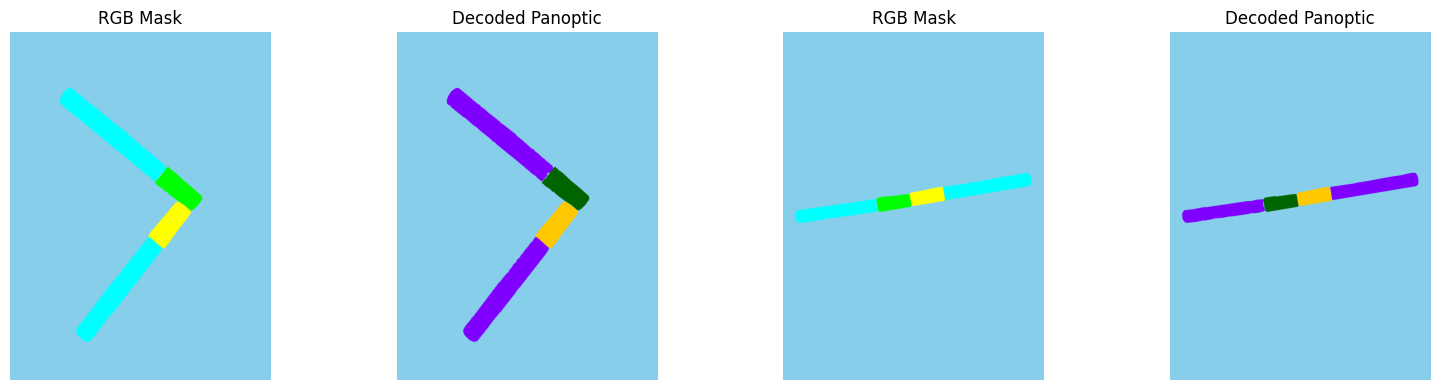

In [2]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# PATHS
# -------------------------
RGB_DIR = "datasets/markerpenspanseg/train/rgbmasks"
MASK_DIR = "datasets/markerpenspanseg/train/masks"

# -------------------------
# DEBUG COLORS (RGB)
# -------------------------
COLOR_CAP1 = np.array([0, 100, 0])        # dark green
COLOR_CAP2 = np.array([255, 200, 0])      # orange-yellow
COLOR_MARKER = np.array([128, 0, 255])    # purple-blue
COLOR_FLOOR = np.array([135, 206, 235])   # sky blue

# -------------------------
# LOAD FILES
# -------------------------
files = [f for f in os.listdir(RGB_DIR) if f.endswith(".png")]
samples = random.sample(files, 2)

# -------------------------
# FUNCTION: decode panoptic → RGB
# -------------------------
def decode_panoptic(mask):
    h, w = mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)

    class_id = mask // 1000
    instance_id = mask % 1000

    # CAP (class 1)
    cap1 = (class_id == 1) & (instance_id == 1)
    cap2 = (class_id == 1) & (instance_id == 2)

    out[cap1] = COLOR_CAP1
    out[cap2] = COLOR_CAP2

    # Marker (class 2)
    marker = (class_id == 2)
    out[marker] = COLOR_MARKER

    # Floor (class 3)
    floor = (class_id == 3)
    out[floor] = COLOR_FLOOR

    return out

# -------------------------
# PLOT
# -------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, fname in enumerate(samples):
    rgb_path = os.path.join(RGB_DIR, fname)
    mask_path = os.path.join(MASK_DIR, fname)

    rgb = cv2.cvtColor(cv2.imread(rgb_path), cv2.COLOR_BGR2RGB)
    panoptic = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    decoded = decode_panoptic(panoptic)

    axes[i*2].imshow(rgb)
    axes[i*2].set_title(f"RGB Mask")
    axes[i*2].axis("off")

    axes[i*2+1].imshow(decoded)
    axes[i*2+1].set_title(f"Decoded Panoptic")
    axes[i*2+1].axis("off")

plt.tight_layout()
plt.show()

In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!pip install -q transformers==4.20.0
!pip install -q datasets torchvision pycocotools accelerate

In [3]:
from huggingface_hub import login
from google.colab import userdata
token = userdata.get('Nyi_token')
login(token=token)

In [4]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from pycocotools.coco import COCO
from pycocotools import mask as mask_utils
from transformers import MaskFormerImageProcessor, MaskFormerForInstanceSegmentation, Trainer, TrainingArguments
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class PanopticDataset(Dataset):
    def __init__(self, image_root, mask_root, processor):
        self.image_root = image_root
        self.mask_root = mask_root
        self.processor = processor

        self.files = sorted(os.listdir(image_root))

        # label mapping (IMPORTANT)
        self.class_map = {
            1: 0,  # CAP
            2: 1,  # Marker
            3: 2   # Floor
        }

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        # -------------------------
        # LOAD IMAGE
        # -------------------------
        img_path = os.path.join(self.image_root, fname)
        image = Image.open(img_path).convert("RGB")
        image = image.resize((800, 800), Image.BILINEAR)

        # -------------------------
        # LOAD PANOPTIC MASK
        # -------------------------
        mask_path = os.path.join(self.mask_root, os.path.splitext(fname)[0] + ".png")
        panoptic = np.array(Image.open(mask_path), dtype=np.int32)

        class_id = panoptic // 1000
        instance_id = panoptic % 1000

        masks = []
        labels = []

        # -------------------------
        # 1. HANDLE CAP (thing)
        # -------------------------
        cap_instances = np.unique(instance_id[class_id == 1])

        for inst_id in cap_instances:
            if inst_id == 0:
                continue

            binary = (class_id == 1) & (instance_id == inst_id)
            if binary.sum() == 0:
                continue

            masks.append(torch.tensor(binary))
            labels.append(self.class_map[1])

        # -------------------------
        # 2. HANDLE MARKER (stuff)
        # -------------------------
        marker_mask = (class_id == 2)
        if marker_mask.sum() > 0:
            masks.append(torch.tensor(marker_mask))
            labels.append(self.class_map[2])

        # -------------------------
        # 3. HANDLE FLOOR (stuff)
        # -------------------------
        # floor_mask = (class_id == 3)
        # if floor_mask.sum() > 0:
        #     masks.append(torch.tensor(floor_mask))
        #     labels.append(self.class_map[3])

        # -------------------------
        # STACK FIRST
        # -------------------------
        if masks:
            masks = torch.stack(masks).float()
        else:
            masks = torch.zeros((0, panoptic.shape[0], panoptic.shape[1]), dtype=torch.float32)

        labels = torch.tensor(labels, dtype=torch.int64)

        # -------------------------
        # RESIZE
        # -------------------------
        if masks.shape[0] > 0:
            masks = masks.unsqueeze(1)
            masks = torch.nn.functional.interpolate(
                masks,
                size=(800, 800),
                mode="nearest"
            ).squeeze(1)

            # 🔥 CRITICAL: re-binarize
            masks = (masks > 0.5).float()

            # 🔥 CRITICAL: remove empty AFTER resize
            valid_masks = []
            valid_labels = []

            for m, l in zip(masks, labels):
                if m.sum() > 0:
                    valid_masks.append(m)
                    valid_labels.append(l)

            if len(valid_masks) == 0:
                # fallback
                dummy = torch.zeros((800, 800), dtype=torch.float32)
                valid_masks = [dummy]
                valid_labels = [0]

            masks = torch.stack(valid_masks)
            labels = torch.tensor(valid_labels, dtype=torch.int64)

        else:
            # fallback
            masks = torch.zeros((1, 800, 800), dtype=torch.float32)
            labels = torch.tensor([0], dtype=torch.int64)

        # -------------------------
        # PROCESS IMAGE
        # -------------------------
        encoded = self.processor(images=image, return_tensors="pt")

        return {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "pixel_mask": encoded["pixel_mask"].squeeze(0),
            "mask_labels": masks,
            "class_labels": labels,
        }

In [ ]:
# Prepare processor and model
processor = MaskFormerImageProcessor.from_pretrained("facebook/maskformer-swin-small-coco")

model = MaskFormerForInstanceSegmentation.from_pretrained(
    "facebook/maskformer-swin-small-coco",
    num_labels=2,
    id2label={0: "CAP", 1: "Marker"},
    label2id={"CAP": 0, "Marker": 1},
    ignore_mismatched_sizes=True
)

In [7]:
# Load datasets (set paths accordingly)
train_dataset = PanopticDataset(
    mask_root="datasets/markerpenspanseg/train/masks",
    image_root="datasets/markerpenspanseg/train/images",
    processor=processor
)
eval_dataset = PanopticDataset(
    mask_root="datasets/markerpenspanseg/valid/masks",
    image_root="datasets/markerpenspanseg/valid/images",
    processor=processor
)

In [8]:
print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(eval_dataset))

Number of training examples: 239
Number of validation examples: 30


In [9]:
example = train_dataset[65]
for k,v in example.items():
  if isinstance(v, torch.Tensor):
    print(k,v.shape)

pixel_values torch.Size([3, 800, 800])
pixel_mask torch.Size([800, 800])
mask_labels torch.Size([3, 800, 800])
class_labels torch.Size([3])


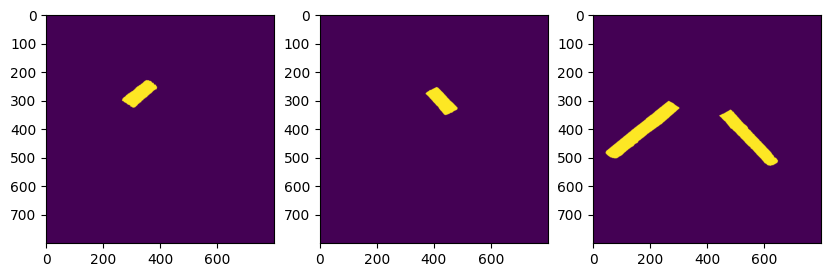

In [10]:
encoded_inputs = train_dataset[97]
encoded_inputs["pixel_values"].shape
encoded_inputs["class_labels"].unique()
fig, axs = plt.subplots(1, len(encoded_inputs['mask_labels']), figsize=(10, 10))

for i in range(len(encoded_inputs['mask_labels'])):
  mask = (encoded_inputs["mask_labels"][i].bool().numpy() * 255).astype(np.uint8)
  axs[i].imshow(mask)
plt.show()

In [11]:
print(model.config.num_labels)

2


In [12]:
print(processor.do_reduce_labels)

False


In [13]:
training_args = TrainingArguments(
    output_dir="./maskformerresults/maskformer-panoptic-custom",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    fp16=True,
    report_to="none"
)

In [14]:
# Define custom data collator
def collate_fn(samples):
    # Stack pixel values and pixel masks as these have fixed dimensions
    pixel_values = torch.stack([s["pixel_values"] for s in samples])
    pixel_mask = torch.stack([s["pixel_mask"] for s in samples])

    # Mask and class labels have variable dimensions (number of instances),
    # so they should be returned as lists of tensors
    mask_labels = [s["mask_labels"] for s in samples]
    class_labels = [s["class_labels"] for s in samples]

    return {
        "pixel_values": pixel_values,
        "pixel_mask": pixel_mask,
        "mask_labels": mask_labels,
        "class_labels": class_labels,
    }

In [15]:
# Train model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collate_fn,
)

In [16]:
batch = next(iter(trainer.get_train_dataloader()))

outputs = model(**batch)
print(outputs.loss)

tensor(2.0317, device='cuda:0', grad_fn=<AddBackward0>)


In [ ]:
trainer.train()

In [17]:
#  [300/300 15:02, Epoch 5/5]
# Epoch	Training Loss	Validation Loss
# 1	No log	0.189463
# 2	No log	0.039448
# 3	No log	0.035610
# 4	No log	0.034191
# 5	No log	0.034125
# TrainOutput(global_step=300, training_loss=0.11230828603108724, metrics={'train_runtime': 914.2983,
# 'train_samples_per_second': 1.307, 'train_steps_per_second': 0.328, 'total_flos': 8.674595888832e+17,
# 'train_loss': 0.11230828603108724, 'epoch': 5.0})

In [18]:
sample = eval_dataset[0]
inputs = {
    k: v.unsqueeze(0).to(model.device) for k, v in sample.items() if k in ['pixel_values', 'pixel_mask']
}

with torch.no_grad():
    outputs = model(**inputs)

print(outputs)

MaskFormerForInstanceSegmentationOutput(loss=None, class_queries_logits=tensor([[[-3.1875, -3.4023,  5.3594],
         [-3.3535, -3.2715,  5.3789],
         [-3.2363, -3.3145,  5.3672],
         [-3.4277, -3.1699,  5.3828],
         [-3.3438, -3.2812,  5.3750],
         [-3.2285, -3.3301,  5.3906],
         [-3.3457, -3.2617,  5.3906],
         [-3.2402, -3.3477,  5.3945],
         [-3.2676, -3.2910,  5.4219],
         [-3.3457, -3.2031,  5.3594],
         [-3.2988, -3.3086,  5.3867],
         [-3.2637, -3.2227,  5.4297],
         [-3.3223, -3.3281,  5.3438],
         [-3.3164, -3.2441,  5.3945],
         [-3.3711, -3.2480,  5.3867],
         [-3.2891, -3.2852,  5.4023],
         [-3.2109, -3.2559,  5.4258],
         [-3.3535, -3.2051,  5.4102],
         [-3.3262, -3.2793,  5.3398],
         [-3.3027, -3.2422,  5.3828],
         [-3.3125, -3.3184,  5.3672],
         [-3.3008, -3.2637,  5.4062],
         [-3.3340, -3.2285,  5.1523],
         [-3.2930, -3.1973,  5.3555],
         [-3.132

In [24]:
import torch
import numpy as np
import cv2
from tqdm import tqdm

@torch.no_grad()
def evaluate_model(model, dataset, processor, device="cuda", threshold=0.5):
    model.eval()
    model.to(device)

    num_classes = 3  # CAP, Marker, Floor (even if floor not trained)

    iou_scores = {i: [] for i in range(num_classes)}

    print("Evaluating...")

    for idx in tqdm(range(len(dataset))):
        sample = dataset[idx]

        pixel_values = sample["pixel_values"].unsqueeze(0).to(device)

        # -------------------------
        # GT → semantic map
        # -------------------------
        gt_masks = sample["mask_labels"]  # (N, H, W)
        gt_labels = sample["class_labels"]

        H, W = gt_masks.shape[-2:]

        gt_map = np.zeros((H, W), dtype=np.int32)

        for m, l in zip(gt_masks, gt_labels):
            gt_map[m.cpu().numpy() > 0.5] = l.item() + 1  # +1 to avoid bg=0

        # -------------------------
        # Prediction
        # -------------------------
        outputs = model(pixel_values=pixel_values)

        pred_logits = outputs.class_queries_logits[0]  # (Q, C)
        pred_masks = outputs.masks_queries_logits[0].sigmoid()  # (Q, H, W)

        probs = pred_logits.softmax(-1)[:, :-1]
        scores, labels = probs.max(-1)

        keep = scores > threshold

        if keep.sum() == 0:
            continue

        pred_masks = pred_masks[keep]
        labels = labels[keep]

        # -------------------------
        # Build predicted semantic map
        # -------------------------
        pred_map = np.zeros((H, W), dtype=np.int32)

        for i in range(len(pred_masks)):
            mask = pred_masks[i].cpu().numpy()

            # 🔥 FIX: resize to GT size
            mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_LINEAR)

            # threshold AFTER resize
            mask = mask > 0.5

            cls = labels[i].item() + 1
            pred_map[mask] = cls

        # -------------------------
        # Compute IoU per class
        # -------------------------
        for cls in range(1, num_classes + 1):
            pred = (pred_map == cls)
            gt = (gt_map == cls)

            intersection = np.logical_and(pred, gt).sum()
            union = np.logical_or(pred, gt).sum()

            if union > 0:
                iou = intersection / union
                iou_scores[cls - 1].append(iou)

    # -------------------------
    # Final metrics
    # -------------------------
    final_iou = {}
    for cls in iou_scores:
        if len(iou_scores[cls]) > 0:
            final_iou[cls] = np.mean(iou_scores[cls])
        else:
            final_iou[cls] = 0.0

    # ignore Floor (class 2)
    valid_classes = [0, 1]

    mIoU = np.mean([final_iou[c] for c in valid_classes])
    # mIoU = np.mean(list(final_iou.values()))

    print("\n📊 Evaluation Results:")
    for cls, val in final_iou.items():
        print(f"Class {cls}: IoU = {val:.4f}")

    print(f"\n🔥 mIoU: {mIoU:.4f}")

    return {
        "iou_per_class": final_iou,
        "mIoU": mIoU
    }

In [ ]:
import os
import re

checkpoint_root = "maskformerresults/maskformer-panoptic-custom"
checkpoints = sorted(
    [d for d in os.listdir(checkpoint_root) if re.match(r"^checkpoint-\d+$", d)],
    key=lambda x: int(x.split("-")[1])
)

results = {}

for ckpt in checkpoints:
    print(f"\nEvaluating {ckpt}...")
    model_path = os.path.join(checkpoint_root, ckpt)
    model = MaskFormerForInstanceSegmentation.from_pretrained(model_path).to("cuda")

    metrics = evaluate_model(model, dataset=eval_dataset, processor=processor, threshold=0.5)
    results[ckpt] = metrics

print("\n📊 Summary of All Checkpoints:")
for ckpt, metrics in results.items():
    print(f"{ckpt}: mIoU={metrics['mIoU']:.4f}")

# Find checkpoint with highest mIoU
best_ckpt = max(results.items(), key=lambda x: x[1]['mIoU'])
print(f"\n🏆 Best checkpoint based on mIoU: {best_ckpt[0]} with mIoU={best_ckpt[1]['mIoU']:.4f}")

In [ ]:
'''
Evaluating checkpoint-240...
{"version_major":2,"version_minor":0,"model_id":"7e5d4283353c45a897c0b4aaf15c1f3b"}
Evaluating...
100%|██████████| 30/30 [00:11<00:00,  2.60it/s]

📊 Evaluation Results:
Class 0: IoU = 0.9431
Class 1: IoU = 0.9492
Class 2: IoU = 0.0000

🔥 mIoU: 0.9462

Evaluating checkpoint-300...
{"version_major":2,"version_minor":0,"model_id":"98cd9bb5a57a4ea48987bb04f9925306"}
Evaluating...
100%|██████████| 30/30 [00:11<00:00,  2.62it/s]

📊 Evaluation Results:
Class 0: IoU = 0.9434
Class 1: IoU = 0.9502
Class 2: IoU = 0.0000

🔥 mIoU: 0.9468

📊 Summary of All Checkpoints:
checkpoint-240: mIoU=0.9462
checkpoint-300: mIoU=0.9468

🏆 Best checkpoint based on mIoU: checkpoint-300 with mIoU=0.9468
'''

In [ ]:
model = MaskFormerForInstanceSegmentation.from_pretrained(
    "maskformerresults/maskformer-panoptic-custom/checkpoint-300",
    config="maskformerresults/maskformer-panoptic-custom/checkpoint-300"
).to("cuda")
model.eval()

# Sanity test
dummy = eval_dataset[0]
pixel_values = dummy["pixel_values"].unsqueeze(0).to("cuda")

with torch.no_grad():
    out = model(pixel_values=pixel_values)

print("Output keys:", out.keys() if out is not None else "None")
print("class_queries_logits shape:", out.class_queries_logits.shape)
print("masks_queries_logits shape:", out.masks_queries_logits.shape)

In [ ]:
# Output keys: odict_keys(['class_queries_logits', 'masks_queries_logits', 'encoder_last_hidden_state', 'pixel_decoder_last_hidden_state', 'transformer_decoder_last_hidden_state'])
# class_queries_logits shape: torch.Size([1, 100, 3])
# masks_queries_logits shape: torch.Size([1, 100, 200, 200])

In [31]:
import torch
import numpy as np
import cv2
from tqdm import tqdm

def compute_iou(mask1, mask2):
    inter = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return inter / union if union > 0 else 0

@torch.no_grad()
def evaluate_instance_metrics(
    model, dataset, device="cuda",
    iou_thresh=0.5, score_thresh=0.5
):
    model.eval()
    model.to(device)

    all_scores = []
    all_matches = []

    total_TP = 0
    total_FP = 0
    total_FN = 0

    print("Evaluating Instance Metrics (CAP)...")

    for idx in tqdm(range(len(dataset))):
        sample = dataset[idx]
        pixel_values = sample["pixel_values"].unsqueeze(0).to(device)

        gt_masks = sample["mask_labels"]
        gt_labels = sample["class_labels"]

        # only CAP
        gt_caps = [m.cpu().numpy() > 0.5
                   for m, l in zip(gt_masks, gt_labels) if l.item() == 0]

        outputs = model(pixel_values=pixel_values)

        pred_logits = outputs.class_queries_logits[0]
        pred_masks = outputs.masks_queries_logits[0].sigmoid()

        probs = pred_logits.softmax(-1)[:, :-1]
        scores, labels = probs.max(-1)

        keep = (scores > score_thresh) & (labels == 0)

        scores = scores[keep]
        pred_masks = pred_masks[keep]

        # resize preds
        preds = []
        for m in pred_masks:
            m = m.cpu().numpy()
            m = cv2.resize(m, (800, 800))
            m = m > 0.5
            preds.append(m)

        matched_gt = set()

        # --- Matching ---
        for pred_mask, score in zip(preds, scores):
            best_iou = 0
            best_gt = -1

            for i, gt_mask in enumerate(gt_caps):
                if i in matched_gt:
                    continue

                iou = compute_iou(pred_mask, gt_mask)
                if iou > best_iou:
                    best_iou = iou
                    best_gt = i

            if best_iou >= iou_thresh:
                matched_gt.add(best_gt)
                all_matches.append(1)   # TP
                total_TP += 1
            else:
                all_matches.append(0)   # FP
                total_FP += 1

            all_scores.append(score.item())

        # --- FN ---
        fn = len(gt_caps) - len(matched_gt)
        total_FN += fn

    # -------------------------
    # Precision / Recall / F1
    # -------------------------
    precision = total_TP / (total_TP + total_FP + 1e-8)
    recall = total_TP / (total_TP + total_FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    # -------------------------
    # AP (ranking-based)
    # -------------------------
    sorted_idx = np.argsort(-np.array(all_scores))
    matches = np.array(all_matches)[sorted_idx]

    tp = np.cumsum(matches)
    fp = np.cumsum(1 - matches)

    precision_curve = tp / (tp + fp + 1e-8)
    recall_curve = tp / (total_TP + total_FN + 1e-8)

    ap = np.mean(precision_curve)

    # -------------------------
    # Output
    # -------------------------
    print("\n📊 Instance Metrics (CAP @ IoU=0.5)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AP50:      {ap:.4f}")

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "ap50": ap
    }

In [32]:
evaluate_instance_metrics(model, eval_dataset, device="cuda", iou_thresh=0.5, score_thresh=0.5)

Evaluating Instance Metrics (CAP)...


100%|██████████| 30/30 [00:11<00:00,  2.59it/s]


📊 Instance Metrics (CAP @ IoU=0.5)
Precision: 0.9836
Recall:    1.0000
F1-score:  0.9917
AP50:      0.9763


{'precision': 0.9836065572158021,
 'recall': 0.9999999998333333,
 'f1': 0.991735532026501,
 'ap50': np.float64(0.9763163676156031)}

In [29]:
@torch.no_grad()
def evaluate_pq(model, dataset, device="cuda", iou_thresh=0.5):
    model.eval()
    model.to(device)

    total_iou = 0
    TP = 0
    FP = 0
    FN = 0

    print("Evaluating Panoptic Quality...")

    for idx in tqdm(range(len(dataset))):
        sample = dataset[idx]
        pixel_values = sample["pixel_values"].unsqueeze(0).to(device)

        gt_masks = sample["mask_labels"]
        gt_labels = sample["class_labels"]

        outputs = model(pixel_values=pixel_values)

        pred_logits = outputs.class_queries_logits[0]
        pred_masks = outputs.masks_queries_logits[0].sigmoid()

        probs = pred_logits.softmax(-1)[:, :-1]
        scores, labels = probs.max(-1)

        keep = scores > 0.5
        pred_masks = pred_masks[keep]
        labels = labels[keep]

        # resize predictions
        pred_instances = []
        for m, l in zip(pred_masks, labels):
            m = m.cpu().numpy()
            m = cv2.resize(m, (800, 800))
            m = m > 0.5
            pred_instances.append((m, l.item()))

        gt_instances = [(m.cpu().numpy() > 0.5, l.item()) for m, l in zip(gt_masks, gt_labels)]

        matched_gt = set()

        for pred_mask, pred_cls in pred_instances:
            best_iou = 0
            best_gt = -1

            for i, (gt_mask, gt_cls) in enumerate(gt_instances):
                if i in matched_gt:
                    continue
                if pred_cls != gt_cls:
                    continue

                iou = compute_iou(pred_mask, gt_mask)
                if iou > best_iou:
                    best_iou = iou
                    best_gt = i

            if best_iou >= iou_thresh:
                TP += 1
                total_iou += best_iou
                matched_gt.add(best_gt)
            else:
                FP += 1

        FN += len(gt_instances) - len(matched_gt)

    pq = total_iou / (TP + 0.5 * FP + 0.5 * FN + 1e-8)

    print(f"\n🔥 PQ: {pq:.4f}")
    print(f"TP: {TP}, FP: {FP}, FN: {FN}")

    return pq

In [30]:
evaluate_pq(model, eval_dataset, device="cuda", iou_thresh=0.5)

Evaluating Panoptic Quality...


100%|██████████| 30/30 [00:18<00:00,  1.66it/s]


🔥 PQ: 0.9394
TP: 90, FP: 1, FN: 0


np.float64(0.9394298263890273)

In [48]:
@torch.no_grad()
def visualize_maskformer_predictions_final(
    model, dataset, device="cuda",
    score_threshold=0.5, num_images=3
):
    import matplotlib.pyplot as plt
    import numpy as np
    import cv2
    from PIL import Image
    import torch
    import os
    import random
    import torch.nn.functional as F

    # COLORS
    COLOR_CAP1   = np.array([0, 100, 0])
    COLOR_CAP2   = np.array([255, 200, 0])
    COLOR_MARKER = np.array([128, 0, 255])
    COLOR_FLOOR  = np.array([135, 206, 235])

    model.eval()
    model.to(device)

    plt.figure(figsize=(6 * num_images, 6))

    id2label = model.config.id2label

    for idx in range(num_images):
        random_idx = random.randint(0, len(dataset) - 1)
        sample = dataset[random_idx]

        pixel_values = sample['pixel_values'].unsqueeze(0).to(device)

        # Load original image
        filename = dataset.files[random_idx]
        img_path = os.path.join(dataset.image_root, filename)
        orig = np.array(Image.open(img_path).convert("RGB"))
        H, W = orig.shape[:2]

        overlay = orig.copy()

        # -------------------------
        # MODEL
        # -------------------------
        outputs = model(pixel_values=pixel_values)

        logits = outputs.class_queries_logits[0]
        masks_logits = outputs.masks_queries_logits[0]

        probs = logits.softmax(-1)[:, :-1]
        scores, labels = probs.max(-1)

        keep = scores > score_threshold

        scores = scores[keep]
        labels = labels[keep]
        masks_logits = masks_logits[keep]

        # -------------------------
        # RESIZE MASKS
        # -------------------------
        masks_logits = F.interpolate(
            masks_logits.unsqueeze(0),
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )[0]

        masks = masks_logits.sigmoid().cpu().numpy()

        alpha = 0.7

        # -------------------------
        # BUILD PANOPTIC MAP
        # -------------------------
        panoptic_map = np.zeros((H, W), dtype=np.int32)

        score_order = np.argsort(-scores.cpu().numpy())

        instance_id = 1
        cap_instances = []

        for i in score_order:
            mask = masks[i] > 0.5
            cls = labels[i].item()

            if mask.sum() == 0:
                continue

            if cls == 0:  # CAP
                panoptic_map[mask] = 1000 + instance_id
                cap_instances.append((instance_id, mask, scores[i].item()))
                instance_id += 1

            elif cls == 1:  # Marker
                panoptic_map[mask] = 2000

        # Fill remaining as FLOOR
        panoptic_map[panoptic_map == 0] = 3000

        # -------------------------
        # COLOR OVERLAY (PANOPTIC)
        # -------------------------
        for val in np.unique(panoptic_map):
            mask = panoptic_map == val

            class_id = val // 1000
            inst_id = val % 1000

            if class_id == 1:  # CAP
                color = COLOR_CAP1 if inst_id % 2 == 0 else COLOR_CAP2

            elif class_id == 2:  # Marker
                color = COLOR_MARKER

            elif class_id == 3:  # Floor
                color = COLOR_FLOOR

            else:
                continue

            overlay[mask] = (
                alpha * color + (1 - alpha) * overlay[mask]
            ).astype(np.uint8)

        # -------------------------
        # DRAW BOX + LABEL (ONLY CAP)
        # -------------------------
        for inst_id, mask, score in cap_instances:
            ys, xs = np.where(mask)

            if len(xs) == 0:
                continue

            x1, y1 = xs.min(), ys.min()
            x2, y2 = xs.max(), ys.max()

            color = COLOR_CAP1 if inst_id % 2 == 0 else COLOR_CAP2

            cv2.rectangle(overlay, (x1, y1), (x2, y2), color.tolist(), 3)

            label_name = id2label[0]

            cv2.putText(
                overlay,
                f"{label_name} {score:.2f}",
                (x1, max(y1 - 10, 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.5,
                (255, 0, 0),
                4,
                cv2.LINE_AA
            )

        # -------------------------
        # SHOW
        # -------------------------
        plt.subplot(1, num_images, idx + 1)
        plt.imshow(overlay)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

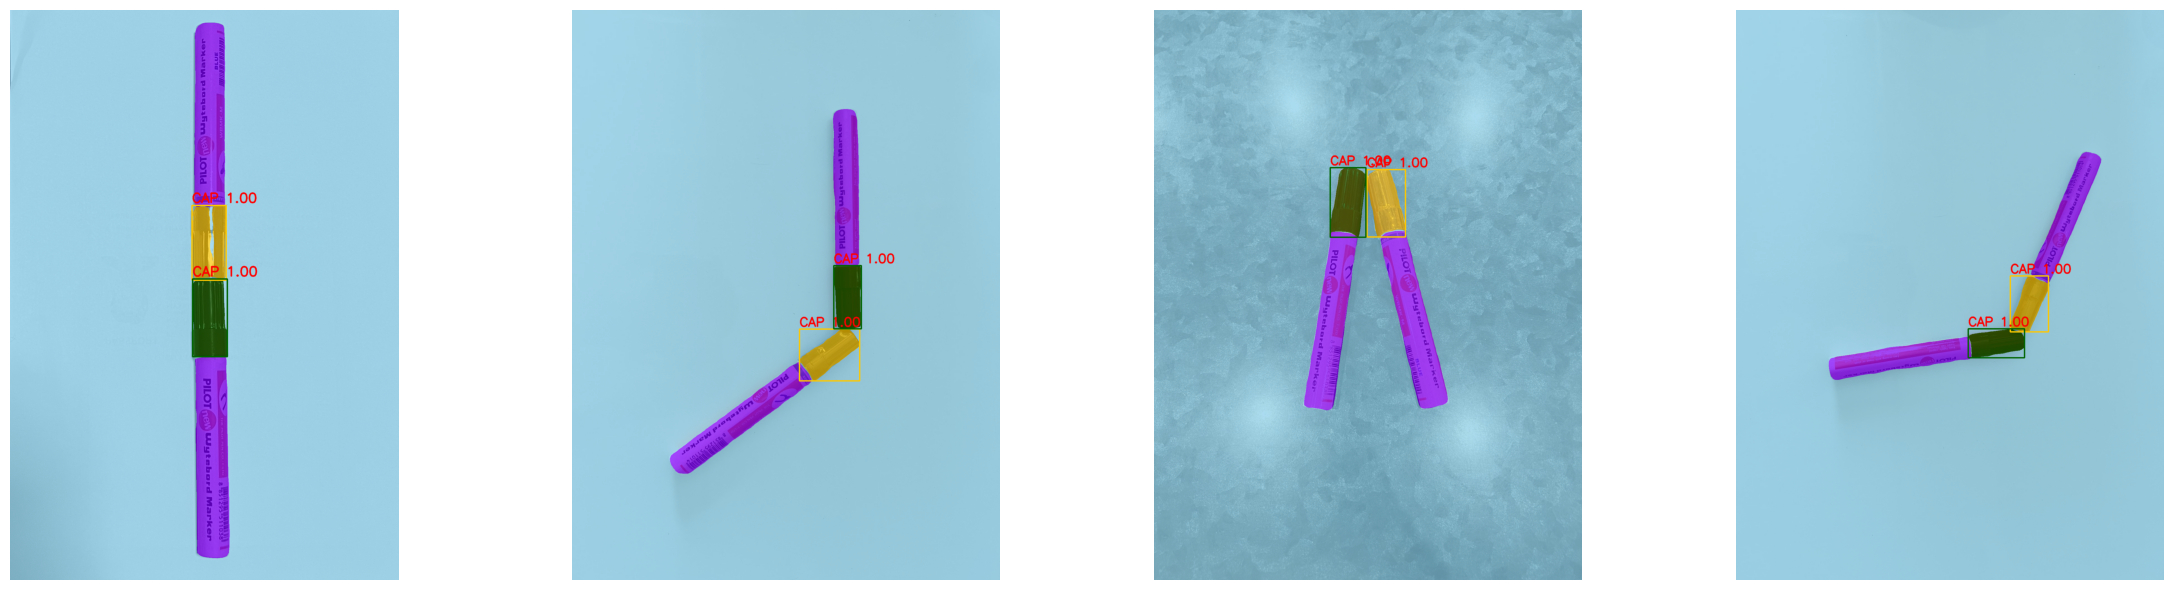

In [49]:
visualize_maskformer_predictions_final(
    model=model,
    dataset=eval_dataset,
    device="cuda",  # or "cpu"
    score_threshold=0.5,
    num_images=4)

In [60]:
@torch.no_grad()
def visualize_gt_vs_pred_panoptic(
    model, dataset, device="cuda",
    score_threshold=0.5, num_images=2
):
    import matplotlib.pyplot as plt
    import numpy as np
    import cv2
    from PIL import Image
    import torch
    import os
    import random
    import torch.nn.functional as F

    # COLORS
    COLOR_CAP1   = np.array([0, 100, 0])
    COLOR_CAP2   = np.array([255, 200, 0])
    COLOR_MARKER = np.array([128, 0, 255])
    COLOR_FLOOR  = np.array([135, 206, 235])

    model.eval()
    model.to(device)

    cols = 4
    rows = int(num_images/2)

    plt.figure(figsize=(6 * cols, 6 * rows))

    for row in range(rows):

        # pick 2 different images per row
        idxs = random.sample(range(len(dataset)), 2)

        for pair_idx, idx in enumerate(idxs):
            sample = dataset[idx]

            pixel_values = sample['pixel_values'].unsqueeze(0).to(device)

            # Load original image
            filename = dataset.files[idx]
            img_path = os.path.join(dataset.image_root, filename)
            orig = np.array(Image.open(img_path).convert("RGB"))
            H, W = orig.shape[:2]

            # =====================================================
            # 🟢 GT PANOPTIC
            # =====================================================
            gt_masks = sample["mask_labels"]
            gt_labels = sample["class_labels"]

            gt_panoptic = np.zeros((H, W), dtype=np.int32)

            inst_id = 1

            for m, l in zip(gt_masks, gt_labels):
                mask = m.unsqueeze(0).unsqueeze(0).float()

                mask = F.interpolate(
                    mask,
                    size=(H, W),
                    mode="nearest"
                )[0, 0].cpu().numpy() > 0.5

                cls = l.item()

                if cls == 0:
                    gt_panoptic[mask] = 1000 + inst_id
                    inst_id += 1
                elif cls == 1:
                    gt_panoptic[mask] = 2000
                elif cls == 2:
                    gt_panoptic[mask] = 3000

            gt_panoptic[gt_panoptic == 0] = 3000

            # COLORIZE GT
            gt_color = orig.copy()
            alpha = 0.7

            for val in np.unique(gt_panoptic):
                mask = gt_panoptic == val

                class_id = val // 1000
                inst_id = val % 1000

                if class_id == 1:
                    color = COLOR_CAP1 if inst_id % 2 == 0 else COLOR_CAP2
                elif class_id == 2:
                    color = COLOR_MARKER
                elif class_id == 3:
                    color = COLOR_FLOOR
                else:
                    continue

                gt_color[mask] = (
                    alpha * color + (1 - alpha) * gt_color[mask]
                ).astype(np.uint8)

            # =====================================================
            # 🔵 PRED PANOPTIC
            # =====================================================
            outputs = model(pixel_values=pixel_values)

            logits = outputs.class_queries_logits[0]
            masks_logits = outputs.masks_queries_logits[0]

            probs = logits.softmax(-1)[:, :-1]
            scores, labels = probs.max(-1)

            keep = scores > score_threshold

            scores = scores[keep]
            labels = labels[keep]
            masks_logits = masks_logits[keep]

            masks_logits = F.interpolate(
                masks_logits.unsqueeze(0),
                size=(H, W),
                mode="bilinear",
                align_corners=False
            )[0]

            masks = masks_logits.sigmoid().cpu().numpy()

            pred_panoptic = np.zeros((H, W), dtype=np.int32)

            score_order = np.argsort(-scores.cpu().numpy())

            inst_id = 1
            cap_instances = []

            for i in score_order:
                mask = masks[i] > 0.5
                cls = labels[i].item()

                if mask.sum() == 0:
                    continue

                if cls == 0:
                    pred_panoptic[mask] = 1000 + inst_id
                    cap_instances.append((inst_id, mask, scores[i].item()))
                    inst_id += 1
                elif cls == 1:
                    pred_panoptic[mask] = 2000

            pred_panoptic[pred_panoptic == 0] = 3000

            # COLORIZE PRED
            pred_overlay = orig.copy()

            for val in np.unique(pred_panoptic):
                mask = pred_panoptic == val

                class_id = val // 1000
                inst_id = val % 1000

                if class_id == 1:
                    color = COLOR_CAP1 if inst_id % 2 == 0 else COLOR_CAP2
                elif class_id == 2:
                    color = COLOR_MARKER
                elif class_id == 3:
                    color = COLOR_FLOOR
                else:
                    continue

                pred_overlay[mask] = (
                    alpha * color + (1 - alpha) * pred_overlay[mask]
                ).astype(np.uint8)

            # DRAW BOXES (CAP only)
            for inst_id, mask, score in cap_instances:
                ys, xs = np.where(mask)

                if len(xs) == 0:
                    continue

                x1, y1 = xs.min(), ys.min()
                x2, y2 = xs.max(), ys.max()

                color = COLOR_CAP1 if inst_id % 2 == 0 else COLOR_CAP2

                cv2.rectangle(pred_overlay, (x1, y1), (x2, y2), color.tolist(), 3)

                cv2.putText(
                    pred_overlay,
                    f"CAP {score:.2f}",
                    (x1, max(y1 - 10, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.5,
                    (255, 0, 0),
                    4,
                    cv2.LINE_AA
                )

            # =====================================================
            # 📊 PLOT (NO DUPLICATION)
            # =====================================================
            base = row * 4 + pair_idx * 2

            plt.subplot(rows, cols, base + 1)
            plt.imshow(gt_color)
            plt.title("GT Panoptic")
            plt.axis("off")

            plt.subplot(rows, cols, base + 2)
            plt.imshow(pred_overlay)
            plt.title("Prediction")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

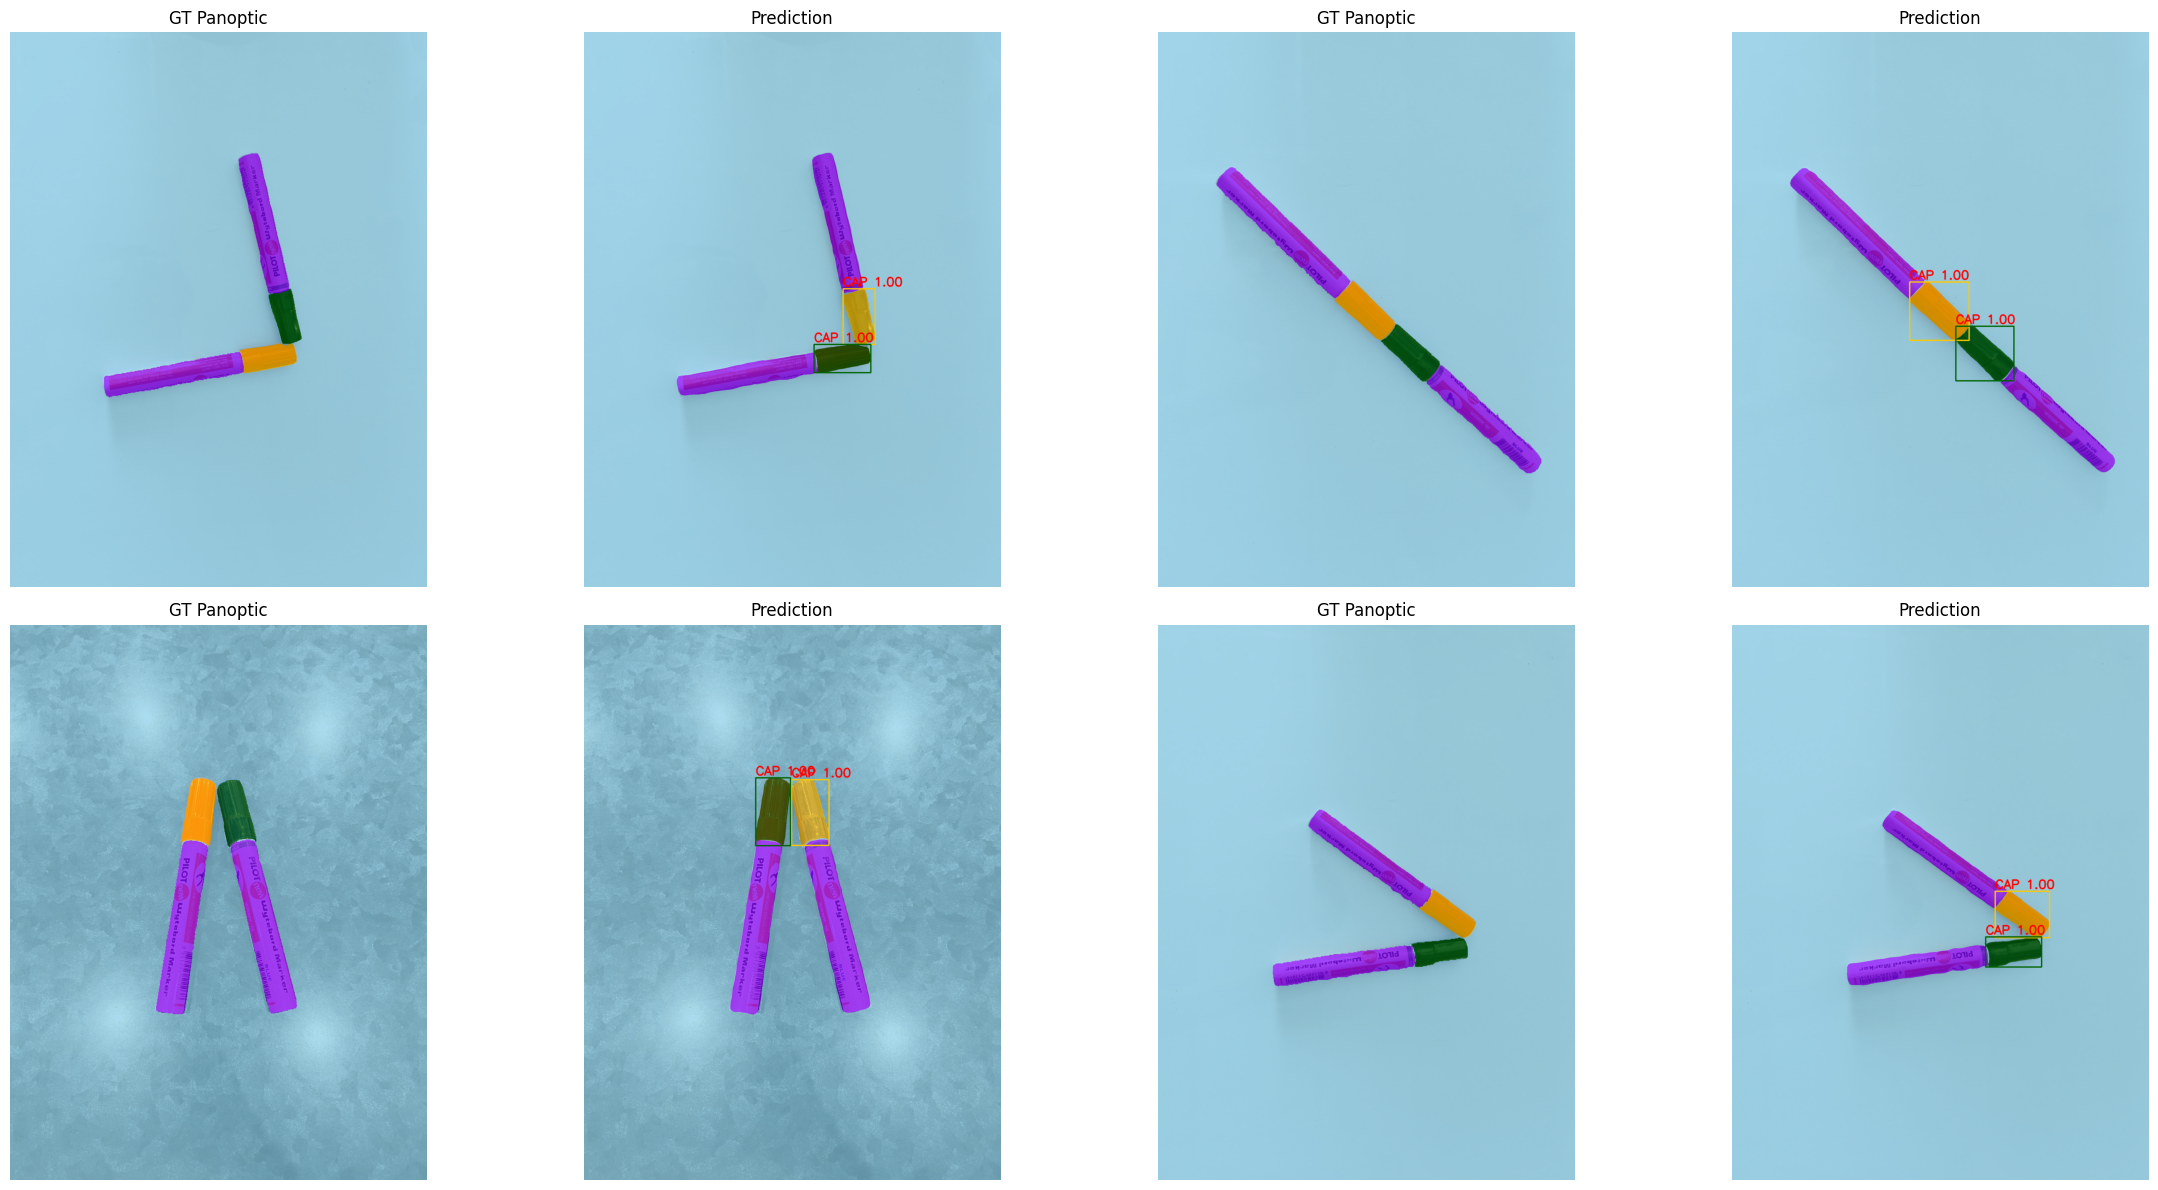

In [68]:
visualize_gt_vs_pred_panoptic(
    model=model,
    dataset=eval_dataset,
    device="cuda",  # or "cpu"
    score_threshold=0.5,
    num_images=4)

In [69]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 18.7 MB/s eta 0:00:00


In [70]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 3.9 MB/s eta 0:00:00


In [71]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [73]:
model = model.to(device)
dummy_input = torch.randn(1, 3, 800, 800).to(device)

In [74]:
onnx_model_path = "maskformerresults/panoptic-checkpoint-300.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_model_path,
    opset_version=16,
    input_names=["input"],
    output_names=["boxes"],
    dynamic_axes={
        "input": {0: "batch_size", 2: "height", 3: "width"},
        "boxes": {0: "num_boxes"},
    },
    do_constant_folding=True,
)
print(f"ONNX export {onnx_model_path} completed successfully!")

/tmp/ipykernel_22810/2410481264.py:2: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0326 18:15:29.837000 22810 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 16 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0326 18:15:30.918000 22810 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1,

[torch.onnx] Obtain model graph for `MaskFormerForInstanceSegmentation([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MaskFormerForInstanceSegmentation([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:65: adapter_lookup: Assertion `false`

Applied 316 of general pattern rewrite rules.
ONNX export maskformerresults/panoptic-checkpoint-300.onnx completed successfully!


In [75]:
import onnxruntime
import numpy as np
import cv2
import torch
import os
import random

# Load image and preprocess
img_path = "datasets/markerpenspanseg/valid/images/1B33B06E-E0AC-4DC7-8B44-98BD83BB987D_jpeg.rf.823192986cba65687f38d10bd84493eb.jpg"

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (800, 800))
img_input = (img_resized[:, :, ::-1].astype(np.float32) ) / 255
img_input = (img_input - mean) / std
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("maskformerresults/panoptic-checkpoint-300.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(1, 100, 3), (1, 100, 200, 200), (1, 768, 25, 25), (1, 256, 200, 200), (1, 100, 256)]


In [81]:
for i, o in enumerate(outputs): print(f"Idx {i}: Max={o.max():.2f}, Min={o.min():.2f}, Shape={o.shape}")

Idx 0: Max=5.51, Min=-3.37, Shape=(1, 100, 3)
Idx 1: Max=23.77, Min=-107.52, Shape=(1, 100, 200, 200)
Idx 2: Max=6.43, Min=-21.72, Shape=(1, 768, 25, 25)
Idx 3: Max=15.66, Min=-19.13, Shape=(1, 256, 200, 200)
Idx 4: Max=3.81, Min=-4.73, Shape=(1, 100, 256)


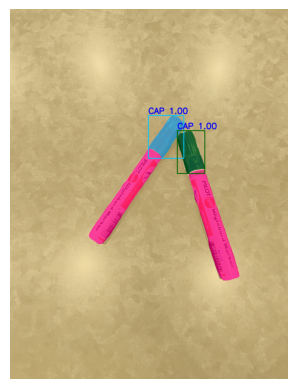

In [83]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt

# COLORS (EXACT SAME)
COLOR_CAP1   = np.array([0, 100, 0])
COLOR_CAP2   = np.array([255, 200, 0])
COLOR_MARKER = np.array([128, 0, 255])
COLOR_FLOOR  = np.array([135, 206, 235])

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -50, 50)))

def visualize_results(img_orig, outputs, threshold=0.5):
    H, W = img_orig.shape[:2]

    # -------------------------
    # OUTPUTS
    # -------------------------
    cls_logits = outputs[0][0]     # (Q, C+1)
    mask_logits = outputs[1][0]    # (Q, Hm, Wm)

    probs = softmax(cls_logits)

    scores = np.max(probs[:, :-1], axis=1)
    labels = np.argmax(probs[:, :-1], axis=1)

    keep = scores > threshold

    scores = scores[keep]
    labels = labels[keep]
    mask_logits = mask_logits[keep]

    # -------------------------
    # RESIZE MASKS (same as torch)
    # -------------------------
    mask_logits = torch.from_numpy(mask_logits).unsqueeze(0)

    mask_logits = F.interpolate(
        mask_logits,
        size=(H, W),
        mode="bilinear",
        align_corners=False
    )[0].numpy()

    masks = sigmoid(mask_logits)

    # -------------------------
    # BUILD PANOPTIC MAP
    # -------------------------
    panoptic_map = np.zeros((H, W), dtype=np.int32)

    score_order = np.argsort(-scores)

    inst_id = 1
    cap_instances = []

    for i in score_order:
        mask = masks[i] > 0.5
        cls = labels[i]

        if mask.sum() == 0:
            continue

        if cls == 0:  # CAP
            panoptic_map[mask] = 1000 + inst_id
            cap_instances.append((inst_id, mask, scores[i]))
            inst_id += 1

        elif cls == 1:  # Marker
            panoptic_map[mask] = 2000

    # Fill floor
    panoptic_map[panoptic_map == 0] = 3000

    # -------------------------
    # COLORIZE (PANOPTIC)
    # -------------------------
    overlay = img_orig.copy()
    alpha = 0.7

    for val in np.unique(panoptic_map):
        mask = panoptic_map == val

        class_id = val // 1000
        inst_id = val % 1000

        if class_id == 1:  # CAP
            color = COLOR_CAP1 if inst_id % 2 == 0 else COLOR_CAP2

        elif class_id == 2:  # Marker
            color = COLOR_MARKER

        elif class_id == 3:  # Floor
            color = COLOR_FLOOR

        else:
            continue

        overlay[mask] = (
            alpha * color + (1 - alpha) * overlay[mask]
        ).astype(np.uint8)

    # -------------------------
    # DRAW BOXES (CAP only)
    # -------------------------
    for inst_id, mask, score in cap_instances:
        ys, xs = np.where(mask)

        if len(xs) == 0:
            continue

        x1, y1 = xs.min(), ys.min()
        x2, y2 = xs.max(), ys.max()

        color = COLOR_CAP1 if inst_id % 2 == 0 else COLOR_CAP2

        cv2.rectangle(overlay, (x1, y1), (x2, y2), color.tolist(), 3)

        cv2.putText(
            overlay,
            f"CAP {score:.2f}",
            (x1, max(y1 - 10, 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.5,
            (255, 0, 0),
            4,
            cv2.LINE_AA
        )

    return overlay

# =========================
# EXECUTE
# =========================
result_viz = visualize_results(img, outputs, threshold=0.5)

plt.imshow(cv2.cvtColor(result_viz, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

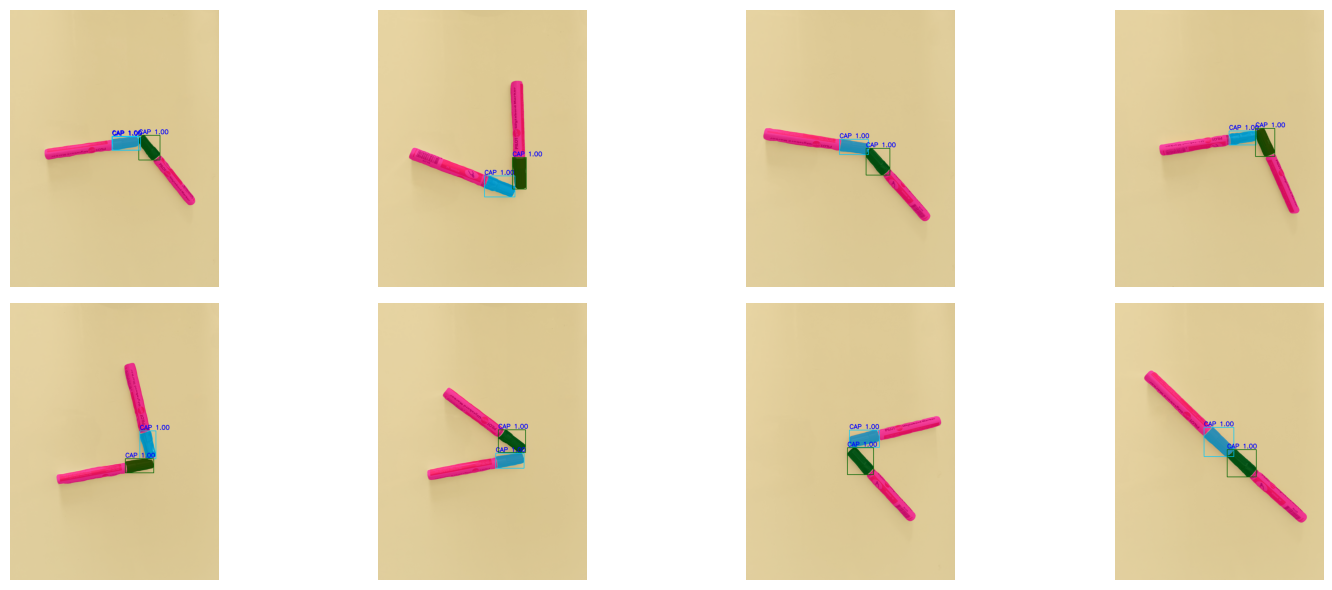

In [84]:
CONF_THR = 0.5

# ---------------- CONFIG ----------------
val_dir = "datasets/markerpenspanseg/valid/images/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (800, 800))
    img_input = (img_resized[:, :, ::-1].astype(np.float32) ) / 255
    img_input = (img_input - mean) / std
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    outputs = session.run(None, {input_name: img_input})

    result_viz = visualize_results(img, outputs, threshold=CONF_THR)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(result_viz, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()